512x512 are too expensive to run and to truly stick to the OG GAP model we have to reduce the model to 256x256 and apply the conditioning for inpainting

Currently trained models have been trained for 15 epochs for the range -40 to -10 and 25 epochs for the range -10 to 12.5

Hoping by the time it reaches 12.5 it is able to denoise the image perfectly. And I hardly believe training for any after 12.5 would take even more compute time.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

if not torch.cuda.is_available():
    raise ValueError("GPU not found, code will run on CPU and can be extremely slow!")
else:
    device = torch.device("cuda:0")

import time
from glob import glob
import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping
import torch.optim as optim
import torch.utils.data as dt

import os
os.chdir('/mnt/c/Users/ankit/Desktop/Msc AIML/msc-project/GAP/gap')
from GAP_UNET_ResBlock_ffhq import UN
from BinomDataset_ffhq_inpaint_noaug import BinomDataset
from DataFolderFFHQ import DataFolder
from inferencev3 import sample_image
from tasks import inpainting
from utils import preprocess, stats, stack_video

In [22]:
from torchvision.transforms.functional import resize
from PIL import Image
def Resize(imgs):
    res = []
    for img in imgs:
        img = resize(img = img, size = 256, interpolation= Image.BILINEAR,  antialias= True)
        res.append(img)
    return res

(-0.5, 255.5, 255.5, -0.5)

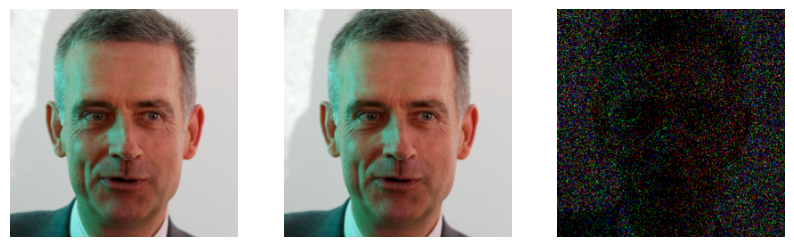

In [71]:
ffhq_path = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/ffhq/'
dataset = DataFolder(ffhq_path, minPSNR = -40, maxPSNR= 15, virtSize= 1)
dataTestGT, dataTestTarget, dataTest = Resize(dataset[0])

plt.figure(figsize= (10, 10))
plt.subplot(1, 3, 1)
plt.imshow(preprocess(dataTestGT))
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(preprocess(dataTestTarget))
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(preprocess(dataTest))
plt.axis('off')


torch.Size([3, 256, 256])


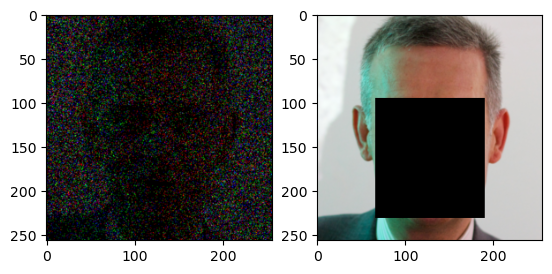

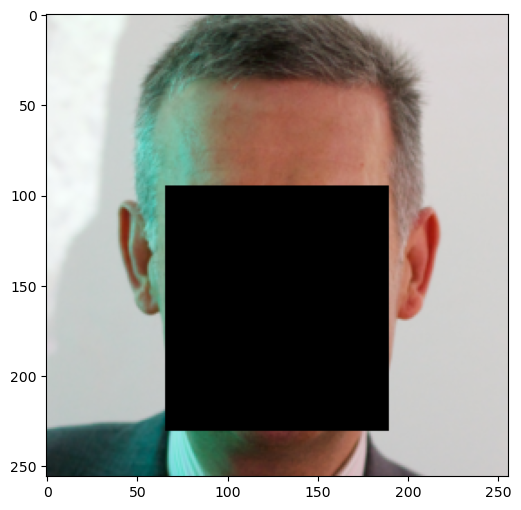

In [72]:
masks = inpainting(imgsize = 256, masksize = 150)
mask = masks.generate_mask().numpy()
test = dataTest 
testGT = dataTestGT/dataTestGT.mean()
cond_test = testGT * (1 - mask)
print(cond_test.shape)
plt.subplot(1, 2, 1)
plt.imshow(preprocess(test))
plt.subplot(1, 2, 2)
plt.imshow(preprocess(cond_test))
plt.figure(figsize= (6, 6))
plt.imshow(preprocess(cond_test))


In [34]:
name = 'm40tom32.5-256x256-ffhq-inpainting-cascade'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade/256x256'

model1 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

name = 'm32.5tom25-256x256-ffhq-inpainting-cascade'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade/256x256'

model2 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

name = 'm25tom17.5-256x256-ffhq-inpainting-cascade'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade/256x256'

model3 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

name = 'm17.5tom10-256x256-ffhq-inpainting-cascade'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade/256x256'

model4 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

name = 'm10tom2.5-256x256-ffhq-inpainting-cascade'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade/256x256'

model5 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

name = 'm2.5to5-256x256-ffhq-inpainting-cascade'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade/256x256'

model6 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

name = '5to12.5-256x256-ffhq-inpainting-cascade'
CHECKPOINT_PATH = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/checkpoints/models/inpainting-cascade/256x256'

model7 = UN.load_from_checkpoint(os.path.join(CHECKPOINT_PATH, name)+'.ckpt').to(device)

In [39]:
cond_img.shape, inp_img.shape

(torch.Size([1, 4, 256, 256]), torch.Size([1, 3, 256, 256]))

cond_input shape torch.Size([1, 4, 256, 256])
cond_img shape torch.Size([1, 4, 256, 256])
input_img shape torch.Size([1, 7, 256, 256])
input_img shape torch.float32
(1, 3, 256, 256)


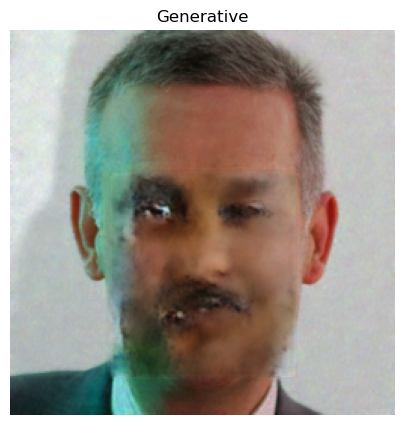

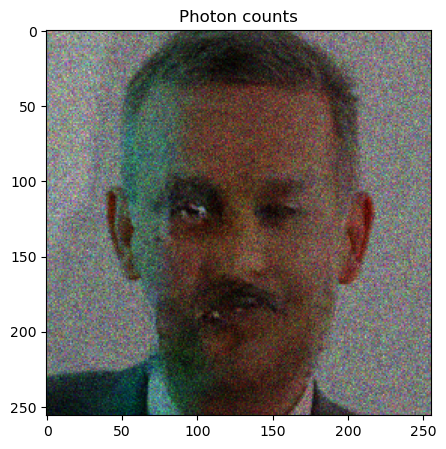

_______________________________________ 346
time (s): 79.51901483535767 time per image (s) 79.51901483535767


In [84]:
from inference_ffhq_cascade import sample_image
import matplotlib.image as mpimg
import time
import numpy as np

# We are starting with an image containing zeros,
# i.e., sampling from scratch

# we just have 1 channel
channels = 3
# we can sample multiple images at the same time in a batch
batch_size = 1
# for best results this should correspond to training pach size
pixels_x = 256
pixels_y = 256

inp_img =  torch.zeros(batch_size ,channels, pixels_y, pixels_x)
# inp_img = dataTest[None]
# masks2 = inpainting(imgsize = 512, masksize = 500)
# mask = masks2.generate_mask().numpy()
cond_input = torch.from_numpy(np.expand_dims(np.concatenate((mask, cond_test), axis = 0), axis = 0))
# cond_input = torch.from_numpy(np.expand_dims(np.concatenate((np.ones_like(mask), np.zeros_like(cond_test)), axis = 0), axis = 0))

print(f'cond_input shape {cond_input.shape}')

cond_img = cond_input
print(f'cond_img shape {cond_img.shape}')

# cond_img = torch.zeros_like(cond_img)
input_img = torch.cat((cond_img, inp_img), 1).to(device)
print(f'input_img shape {input_img.shape}')
print(f'input_img shape {input_img.dtype}')


for i in range(1):
    

    startTime = time.time()
    
    # sampling the image(s)
    denoised, photons, stack, iterations = sample_image(input_img,
                                                        [model1, model2, model3, model4, model5, model6, model7], 
                                                        beta = 0.005,
                                                        save_every_n = 10,
                                                        max_psnr = -33,
                                                        max_its = 50000000,
                                                        channels = 3)

    
    # In case we do multiple images in a batch, we show all of them.
    for j in range(denoised.shape[0]):
#         print(iterations)
            # print(denoised.shape)
            # plt.figure(figsize = (5,5))
            # plt.imshow(denoised[j].transpose(1, 2, 0), cmap='inferno', vmin = 0,
            #            vmax = np.percentile(denoised[j],99.99))
            # plt.title('Generative')
            # plt.axis('off')
            # plt.show()
            
            # plt.figure(figsize = (5,5))
            # plt.imshow(photons[j,0], cmap='inferno', vmin = 0,
            #            vmax = np.percentile(photons[j],99.99))
            # plt.title('Photon counts')
            # plt.show()
            denoised/=denoised.mean()
            print(denoised.shape)
            plt.figure(figsize = (5,5))
            plt.imshow(preprocess(denoised[0]), vmin = 0,
                       vmax = np.percentile(preprocess(denoised[0]),99.99))
            plt.title('Generative')
            plt.axis('off')
            plt.show()
            
            plt.figure(figsize = (5,5))
            plt.imshow(preprocess(photons[0]), vmin = 0,
                       vmax = np.percentile(preprocess(photons[0]),99.99))
            plt.title('Photon counts')
            plt.show()
            
            
    
    print('_______________________________________', iterations)
    
    
    
    
    endTime = time.time()
    elapsedTime = endTime - startTime
    print ('time (s):', elapsedTime, 'time per image (s)', elapsedTime/denoised.shape[0])
   

In [85]:
len(stack)

220

0
psnr : -40


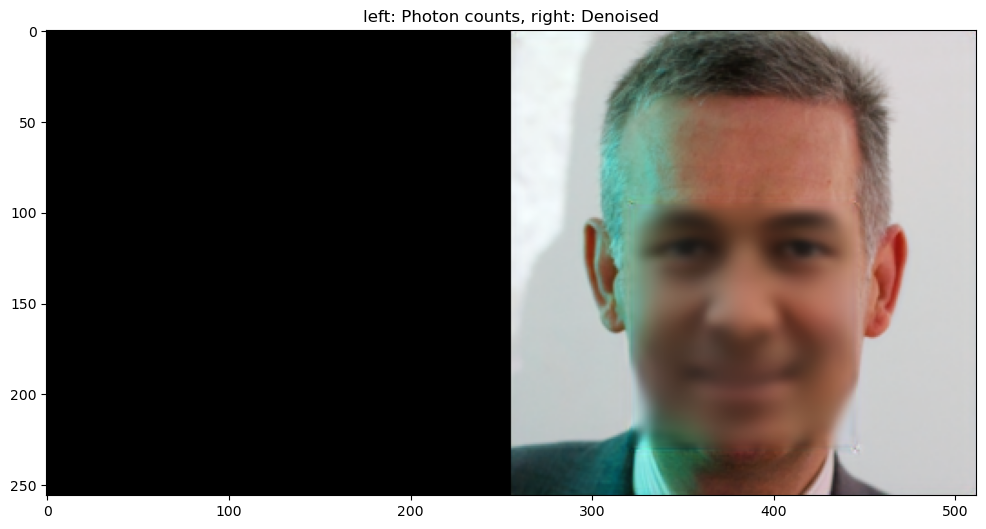

20
psnr : -29.77630839886444


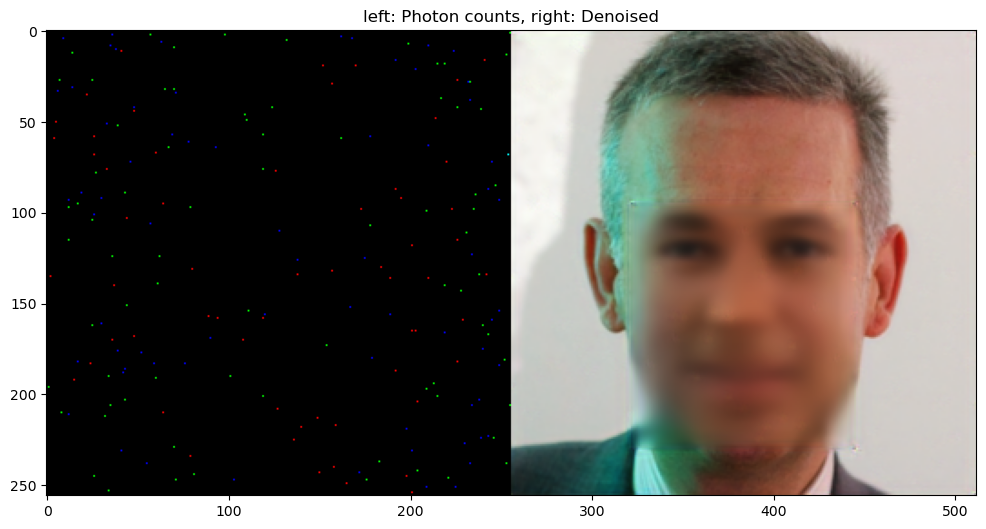

40
psnr : -25.66873963883754


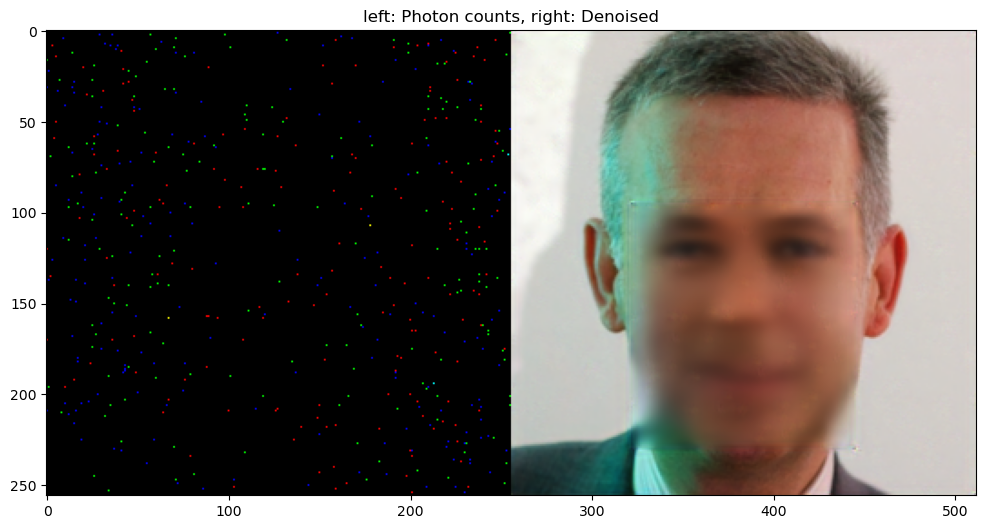

60
psnr : -21.565637305538488


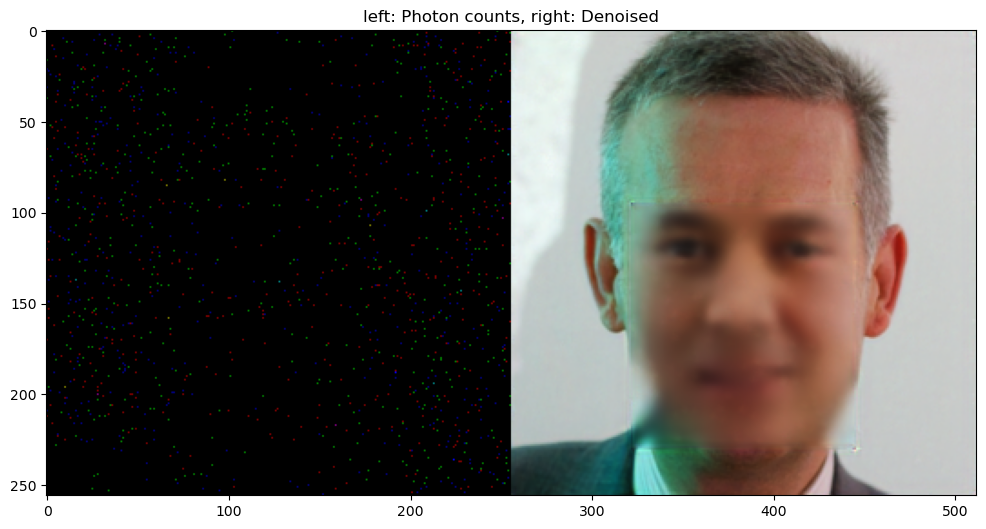

80
psnr : -17.272815638185502


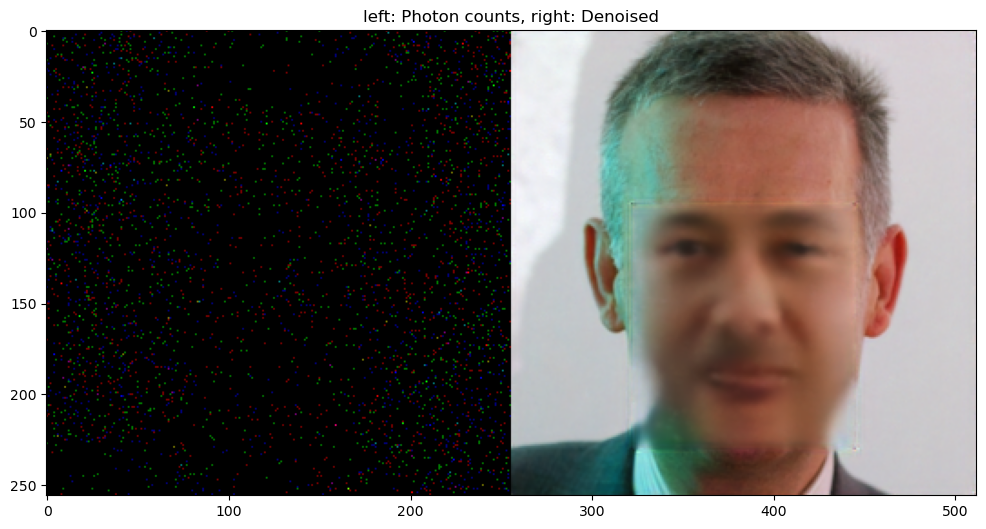

100
psnr : -12.981853653701382


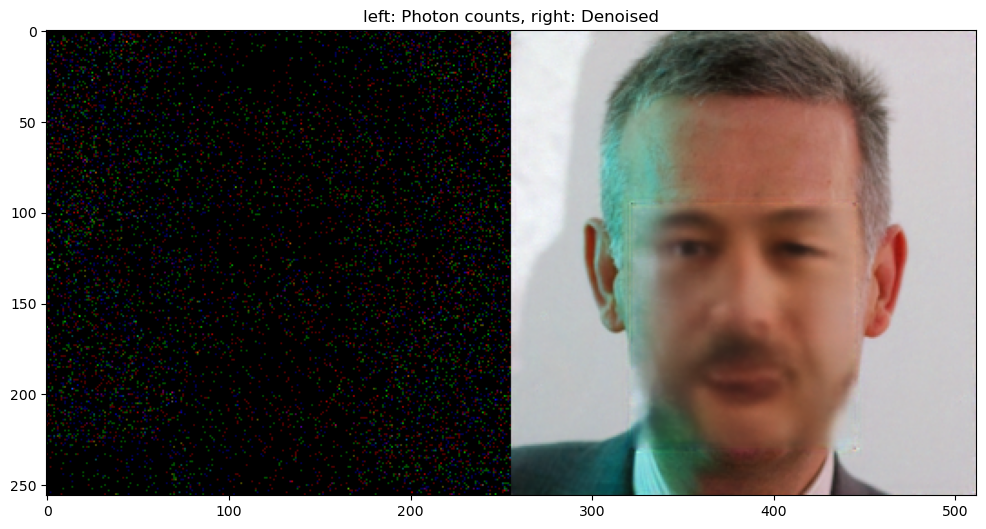

120
psnr : -8.935296532327243


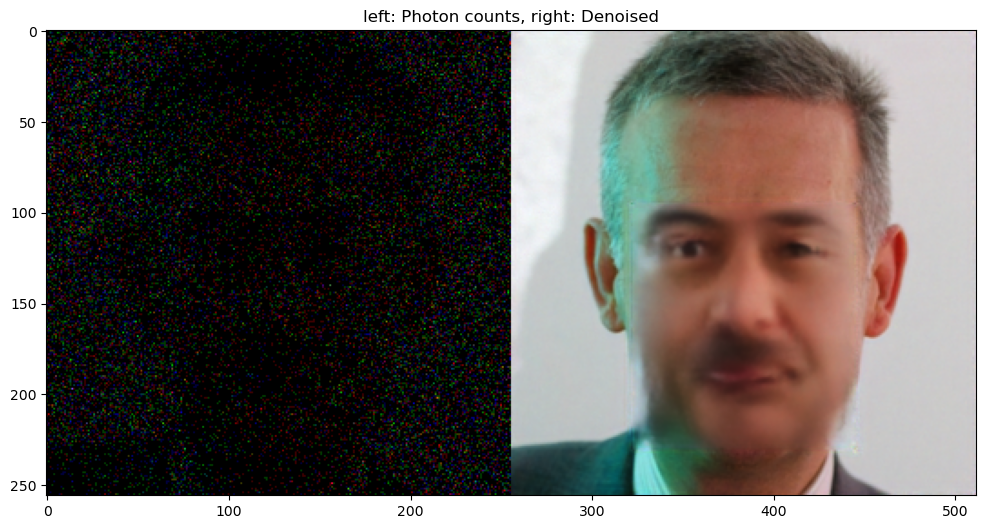

140
psnr : -4.604285525041043


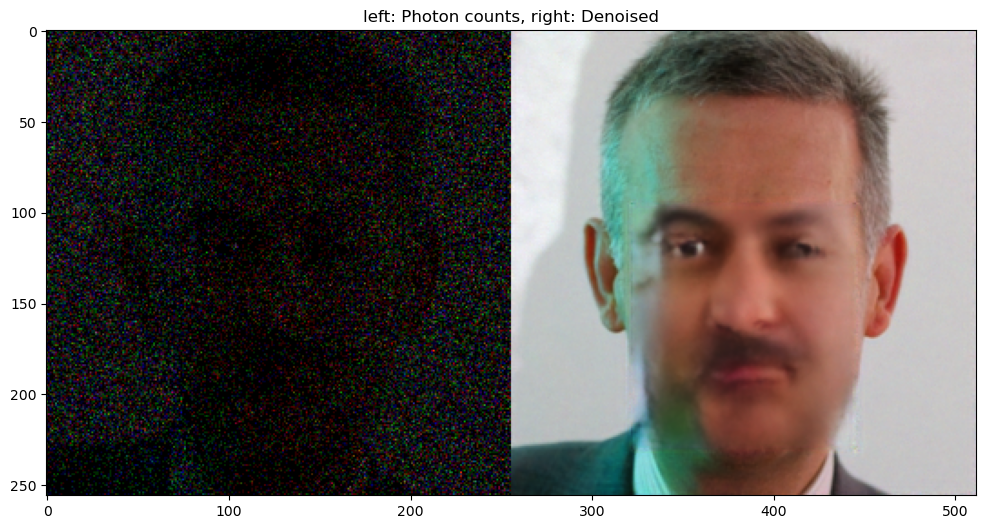

160
psnr : -0.32224087585192374


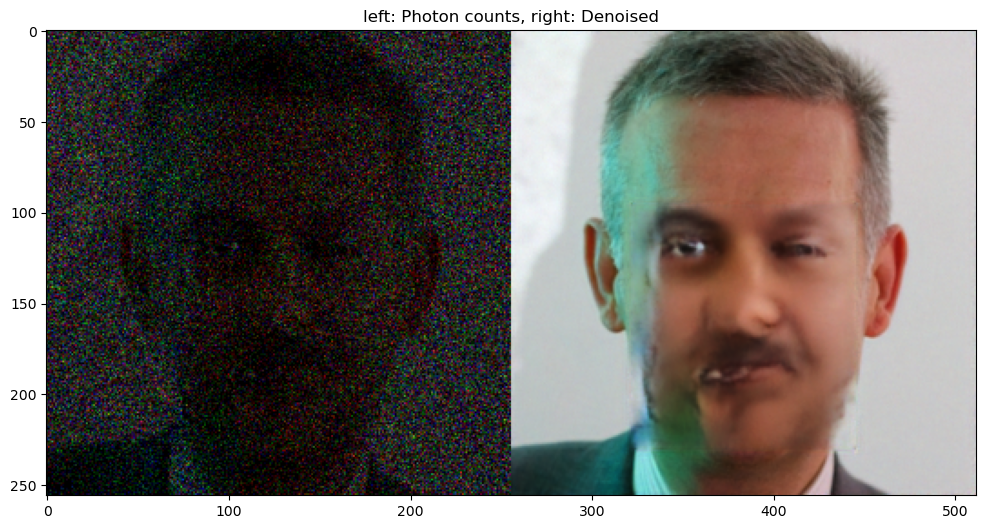

180
psnr : 4.013267767651614


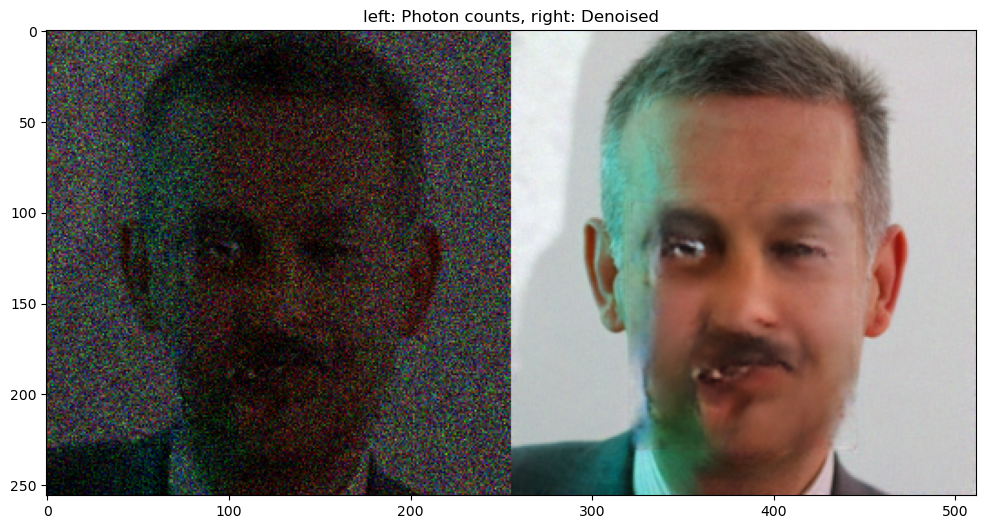

200
psnr : 8.261089121131267


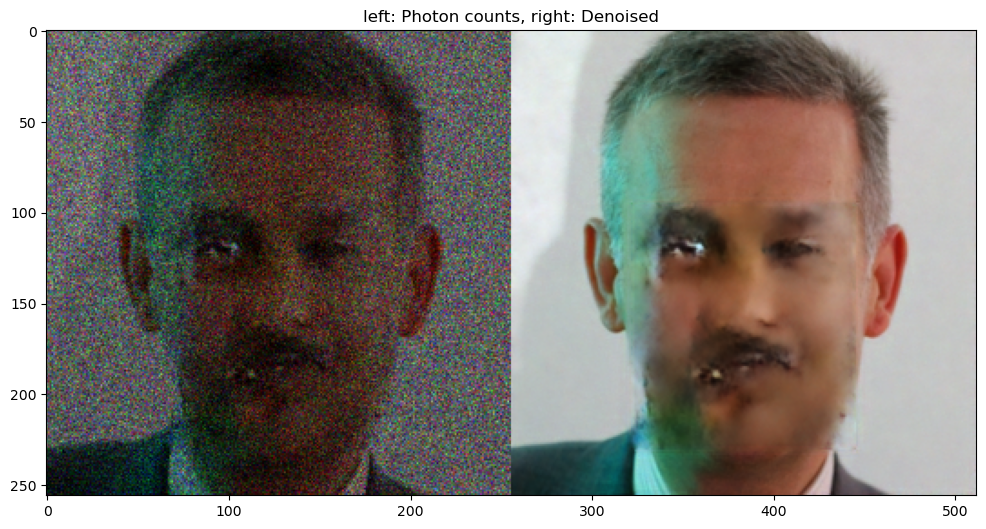

In [86]:
for i in range(len(stack)):
    if i%20 == 0 :
        im = (stack[i][0].transpose(1, 2, 0) * 255).astype(np.uint8)
        print(i)
        print(f'psnr : {stack[i][1]}')
        plt.figure(figsize = (12,12))
        plt.imshow(im, vmax = 0.9)
        plt.title('left: Photon counts, right: Denoised')
        plt.show()

In [69]:
stats(photons)


Shape : (1, 3, 256, 256)

Min : 0.0

Max : 58.140625

Sum : 3502063.25

Mean : 17.812414169311523

